# Bitcoin Price Movement Prediction: Sentiment & Technical Indicators

This notebook establishes a rolling-window machine learning pipeline to predict Bitcoin price movements. It evaluates the predictive power of various technical indicator combinations alongside hourly sentiment data.

## 1. Data Loading and Preprocessing
* **Inputs:** `Bitcoin_sentiment_hourly.csv` and `btc_hourly_indicators.csv`
* **Alignment:** Inner merge on `timestamp`. Data is strictly filtered to start from `2018-01-01`.
* **Target Variable:** The continuous return of the next hour (`next_1h_return`), allowing for robust regression error metrics (RMSE, SMAPE) and derivable classification states (Bullish > 0, Bearish <= 0).

In [1]:
import pandas as pd
import numpy as np
import warnings
from hmmlearn.hmm import GaussianHMM # <-- Added for latent regime detection
warnings.filterwarnings('ignore')

# --- 1. Load Datasets ---
print("Loading datasets...")
df_indicators = pd.read_csv('btc_hourly_indicators.csv')
df_sentiment = pd.read_csv('Bitcoin_sentiment_hourly.csv')

# --- 2. Robust Datetime Conversion ---
# format='ISO8601' handles the varying microsecond precision automatically
print("Converting timestamps using ISO8601 format...")
df_indicators['timestamp'] = pd.to_datetime(df_indicators['timestamp'], utc=True, format='ISO8601')
df_sentiment['timestamp'] = pd.to_datetime(df_sentiment['timestamp'], utc=True, format='ISO8601')

# --- 3. Filter to 2018 Onwards ---
# Create a UTC-aware start date to match the column's timezone
start_date = pd.to_datetime('2018-01-01 00:00:00', utc=True)

print(f"Filtering data from {start_date}...")
df_indicators = df_indicators[df_indicators['timestamp'] >= start_date]
df_sentiment = df_sentiment[df_sentiment['timestamp'] >= start_date]

# --- 4. Merge Datasets ---
print("Merging data on timestamp...")
df_master = pd.merge(df_indicators, df_sentiment, on='timestamp', how='inner')
df_master = df_master.sort_values('timestamp').reset_index(drop=True)

# --- 5. Create Target Variables (Regression) ---
# Shift to get the return for the NEXT hour
df_master['next_close'] = df_master['close'].shift(-1)
df_master['target_return'] = (df_master['next_close'] - df_master['close']) / (df_master['close'] + 1e-10)

# Movement label for EDA and SHAP interpretation
df_master['target_movement'] = np.where(df_master['target_return'] > 0, 'Bullish', 'Bearish')

# Drop the last row as it won't have a future target
df_master = df_master.dropna(subset=['target_return']).reset_index(drop=True)

print(f"✅ Merge Complete! Total Rows: {len(df_master)}")
print(f"Dataset Timeline: {df_master['timestamp'].min()} to {df_master['timestamp'].max()}")

Loading datasets...
Converting timestamps using ISO8601 format...
Filtering data from 2018-01-01 00:00:00+00:00...
Merging data on timestamp...
✅ Merge Complete! Total Rows: 70127
Dataset Timeline: 2018-01-01 00:00:00+00:00 to 2025-12-31 22:00:00+00:00


## 2. Feature Relevance and Statistical Validation

This section performs a rigorous analysis of the merged dataset to validate its predictive potential:
1. **Class Distribution Test:** Checking the balance between positive (Bullish) and negative (Bearish) samples in the regression target.
2. **Correlation Analysis (Feature Importance):** Using `corrwith` to calculate Pearson correlation between all features and the `target_return`.
3. **Statistical Tests:**
   * **ADF Test:** Checking for stationarity (critical for time-series forecasting).
   * **Normality Test:** Checking the distribution of hourly returns.
   * **Significance Testing:** Calculating p-values for the top-performing features.

Running Feature Relevance and Statistical Tests...



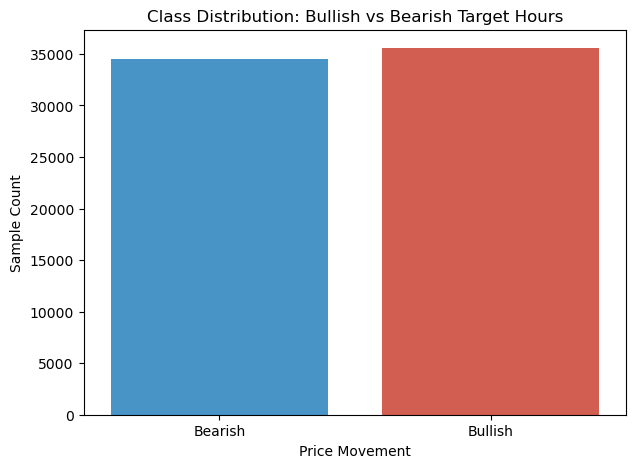

Calculating Feature Correlations with target_return...


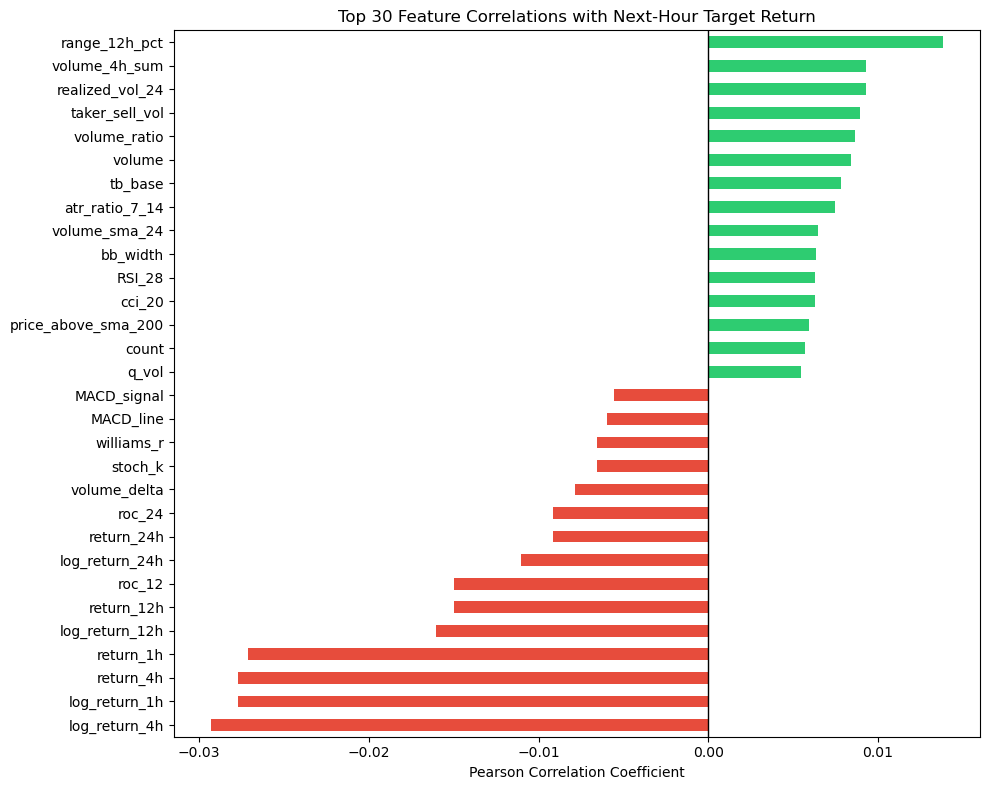


  STATISTICAL VALIDATION RESULTS
ADF Statistic: -37.5500
ADF p-value: 0.0000e+00
✅ Result: Target is Stationary (p < 0.05). Ready for time-series modeling.

Normality Test p-value: 0.0000e+00
ℹ️ Note: Returns follow a non-normal distribution (standard for high-frequency crypto).

Top 5 Most Correlated Features Significance (p-values):
 - log_return_4h         : r=-0.0293, p=7.9312e-15
 - log_return_1h         : r=-0.0277, p=2.1655e-13
 - return_4h             : r=-0.0277, p=2.1673e-13
 - return_1h             : r=-0.0271, p=7.0840e-13
 - log_return_12h        : r=-0.0160, p=2.1672e-05


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, normaltest
from statsmodels.tsa.stattools import adfuller

print("Running Feature Relevance and Statistical Tests...\n")

# --- 1. Class Distribution Test ---
plt.figure(figsize=(7, 5))
sns.countplot(data=df_master, x='target_movement', palette=['#3498db', '#e74c3c'])
plt.title("Class Distribution: Bullish vs Bearish Target Hours")
plt.xlabel("Price Movement")
plt.ylabel("Sample Count")
plt.show()

# --- 2. Correlation with Target (Feature Importance Test) ---
# First select ONLY numeric columns
numeric_df = df_master.select_dtypes(include=[np.number])

# Then drop only the target-related columns that are actually in that numeric list
exclude_numeric = ['target_return', 'next_close']
cols_to_check = [c for c in exclude_numeric if c in numeric_df.columns]
feature_df = numeric_df.drop(columns=cols_to_check)

print("Calculating Feature Correlations with target_return...")
correlations = feature_df.corrwith(df_master['target_return']).sort_values()

# Plotting top 15 most positive and top 15 most negative correlations
top_features = pd.concat([correlations.head(15), correlations.tail(15)])
plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color=np.where(top_features > 0, '#2ecc71', '#e74c3c'))
plt.title("Top 30 Feature Correlations with Next-Hour Target Return")
plt.xlabel("Pearson Correlation Coefficient")
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

# --- 3. Statistical Validation ---
print("\n" + "="*40)
print("  STATISTICAL VALIDATION RESULTS")
print("="*40)

# ADF Test for Stationarity
adf_res = adfuller(df_master['target_return'])
print(f"ADF Statistic: {adf_res[0]:.4f}")
print(f"ADF p-value: {adf_res[1]:.4e}")
if adf_res[1] < 0.05:
    print("✅ Result: Target is Stationary (p < 0.05). Ready for time-series modeling.")
else:
    print("⚠️ Warning: Target is Non-Stationary.")

# Normality Test (D'Agostino's K-squared)
k2, p_norm = normaltest(df_master['target_return'])
print(f"\nNormality Test p-value: {p_norm:.4e}")
if p_norm < 0.05:
    print("ℹ️ Note: Returns follow a non-normal distribution (standard for high-frequency crypto).")

# Correlation Significance (P-Values for top 5 features)
print("\nTop 5 Most Correlated Features Significance (p-values):")
top_5 = correlations.abs().sort_values(ascending=False).head(5).index
for feat in top_5:
    r, p_val = pearsonr(df_master[feat], df_master['target_return'])
    print(f" - {feat:22}: r={r:7.4f}, p={p_val:.4e}")

## 3. Experiment Configuration and Feature Grouping

To rigorously test the predictive power of different data types, we define 10 specific feature variations. Each variation will be tested both with and without the sentiment data to isolate its contribution.

### Configuration Parameters:
* **Training Window:** 4 Months 
* **Testing Window:** 1 Month 
* **Rolling Strategy:** The windows will slide forward by 1 month for each experiment until the end of the dataset.
* **Feature Sets:** Defined based on technical categories (Momentum, Volatility, etc.).

In [ ]:
from dateutil.relativedelta import relativedelta

# --- 1. Define Feature Groups ---
# Identifying columns from btc_hourly_indicators.csv
ohlcv = ['open', 'high', 'low', 'close', 'volume']
order_flow = ['taker_sell_vol', 'volume_delta', 'avg_trade_size', 'vol_delta_sma_24', 'avg_trade_size_sma_24', 'vol_delta_ema_24']
returns = [c for c in df_master.columns if 'return_' in c and 'target' not in c]
momentum = ['RSI_7', 'RSI_14', 'RSI_28', 'stoch_k', 'stoch_d', 'williams_r', 'roc_12', 'roc_24', 'cci_20', 'autocorr_1h_24h']
trend_ind = ['ema_12', 'ema_26', 'sma_50', 'sma_200', 'MACD_line', 'MACD_signal', 'MACD_histogram', 'ema_12_26_cross', 'price_above_sma_200', 'adx_14']
volatility = ['ATR_14', 'ATR_7', 'atr_ratio_7_14', 'bb_upper', 'bb_lower', 'bb_mid', 'bb_width', 'bb_pct', 'realized_vol_24']
volume = ['volume_sma_24', 'volume_ratio', 'obv', 'obv_ema_24', 'obv_slope_5', 'vwap_ratio']
multi_tf = ['close_4h_sma', 'volume_4h_sum', 'high_12h', 'low_12h', 'range_12h_pct']
temporal = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']

# Sentiment columns (everything from the sentiment file excluding timestamp)
sentiment_cols = [c for c in df_sentiment.columns if c != 'timestamp']

# 10 Variations 
feature_variations = {
    "1_OHLCV": ohlcv,
    "2_Order_Flow": ohlcv + order_flow,
    "3_Returns": ohlcv + returns,
    "4_Momentum": ohlcv + momentum,
    "5_Trend": ohlcv + trend_ind,
    "6_Volatility": ohlcv + volatility,
    "7_Volume": ohlcv + volume,
    "8_Multi_TF": ohlcv + multi_tf,
    "9_Temporal": ohlcv + temporal,
    "10_All_Indicators": ohlcv + order_flow + returns + momentum + trend_ind + volatility + volume + multi_tf + temporal
}

# --- 2. Rolling Window Configuration ---
train_window_months = 4 
test_window_months = 1  

def get_rolling_windows(df, train_m, test_m):
    windows = []
    start_date = df['timestamp'].min()
    end_limit = df['timestamp'].max()
    
    current_train_start = start_date
    while True:
        train_end = current_train_start + relativedelta(months=train_m)
        test_end = train_end + relativedelta(months=test_m)
        
        if test_end > end_limit:
            break
            
        windows.append({
            'train_start': current_train_start,
            'train_end': train_end,
            'test_start': train_end,
            'test_end': test_end
        })
        
        # Slide forward by 1 month 
        current_train_start = current_train_start + relativedelta(months=1)
        
    return windows

rolling_windows = get_rolling_windows(df_master, train_window_months, test_window_months)
print(f"Total experiments to run: {len(rolling_windows)}")
print(f"Example Experiment 1: Train {rolling_windows[0]['train_start'].date()} to {rolling_windows[0]['train_end'].date()} | Test until {rolling_windows[0]['test_end'].date()}")

Total experiments to run: 91
Example Experiment 1: Train 2018-01-01 to 2018-05-01 | Test until 2018-06-01


## 4. Model Evaluation Metrics

This section defines the engine for our experiments:
1. **Absolute Price Metrics:** Calculates SMAPE, MAPE, RMSE, MAE, and MSE on reconstructed dollar prices to avoid near-zero denominator inflation.
2. **Return Metrics:** Calculates Directional Accuracy (DA) and Information Coefficient (IC) on the fractional returns to evaluate trend prediction.

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from scipy.stats import spearmanr

# --- 1. Metric Functions ---
def calculate_metrics(y_true_ret, y_pred_ret, y_true_price, y_pred_price):
    """
    Calculates error metrics on reconstructed absolute prices (to fix SMAPE/MAPE),
    and directional/correlation metrics on the fractional returns.
    """
    # 1. Absolute Price Metrics
    mse = mean_squared_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_price, y_pred_price)
    
    # Using absolute prices for denominators fixes the fractional return inflation
    denominator = (np.abs(y_true_price) + np.abs(y_pred_price)) / 2.0
    smape = np.mean(np.abs(y_true_price - y_pred_price) / (denominator + 1e-10)) * 100
    mape_val = np.mean(np.abs((y_true_price - y_pred_price) / (y_true_price + 1e-10))) * 100

    # 2. Return Metrics (Direction and Correlation)
    da = np.mean(np.sign(y_true_ret) == np.sign(y_pred_ret)) * 100
    
    # Information Coefficient (Spearman Rank Correlation)
    if np.std(y_true_ret) == 0 or np.std(y_pred_ret) == 0:
        ic = 0.0
    else:
        ic, _ = spearmanr(y_true_ret, y_pred_ret)
        if np.isnan(ic):
            ic = 0.0
            
    # Include R2 for completeness, calculated on the price
    r2 = r2_score(y_true_price, y_pred_price)
        
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape_val,
        'SMAPE': smape,
        'DA': da,
        'IC': ic
    }

print("✅ Metrics objective defined.")

## 5. Main Walk-Forward Experiment Loop

This loop executes the core training strategy with integrated regime detection:
1. **Iterates** through each 4-month train / 1-month test window.
2. **HMM Regime Detection:** Trains a Gaussian HMM *once* per window on historical returns and volatility to classify the latent market state (Bull/Bear/Ranging).
3. **Tests Variations:** Evaluates the 10 feature variations, both with and without Sentiment.
4. **Hyperparameter Tuning:** Uses Optuna (30 trials) to dynamically find the best Random Forest parameters for the specific market regime.
5. **Price Reconstruction:** Converts predicted fractional returns back into absolute dollar prices to accurately calculate SMAPE and MAPE without zero-bound distortion.
6. **Incremental Saving:** Saves results to `walk_forward_results_hmm_reconstructed.csv` after every single iteration to prevent data loss.

In [6]:
import time
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import optuna
from tqdm.auto import tqdm
from hmmlearn.hmm import GaussianHMM
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING) 

print(f"🚀 Starting Walk-Forward Validation ({len(rolling_windows)} windows)...")

results = []
n_optuna_trials = 30  

for i, window in enumerate(tqdm(rolling_windows)):
    train_start, train_end = window['train_start'], window['train_end']
    test_start, test_end = window['test_start'], window['test_end']
    
    train_df = df_master[(df_master['timestamp'] >= train_start) & (df_master['timestamp'] < train_end)]
    test_df = df_master[(df_master['timestamp'] >= test_start) & (df_master['timestamp'] < test_end)]
    
    if len(train_df) < 100 or len(test_df) < 24:
        continue
        
    # ==========================================
    # HMM LATENT REGIME DETECTION (Train Once per Window)
    # ==========================================
    hmm_features = ['return_1h', 'realized_vol_24'] 
    
    if not all(f in train_df.columns for f in hmm_features):
        raise KeyError(f"Missing HMM features. Ensure {hmm_features} are in df_master.")
        
    X_train_hmm = train_df[hmm_features].fillna(0).values
    X_test_hmm = test_df[hmm_features].fillna(0).values
    
    hmm_model = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42)
    hmm_model.fit(X_train_hmm)
    
    train_regimes = hmm_model.predict(X_train_hmm)
    test_regimes = hmm_model.predict(X_test_hmm)
    # ==========================================
        
    for var_name, base_features in feature_variations.items():
        for use_sentiment in [False, True]:
            current_features = base_features.copy()
            if use_sentiment:
                current_features.extend(sentiment_cols)
                
            valid_features = [f for f in current_features if f in train_df.columns]
            
            X_train = train_df[valid_features].copy()
            y_train = train_df['target_return'].copy()
            
            X_test = test_df[valid_features].copy()
            y_test = test_df['target_return'].copy()
            
            # Add HMM regime as a feature
            X_train['hmm_regime'] = train_regimes
            X_test['hmm_regime'] = test_regimes

            # -----------------------------------------------------
            # HERE IS THE MISSING OBJECTIVE FUNCTION (Inside the loop)
            # -----------------------------------------------------
            def objective(trial):
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 200),
                    'max_depth': trial.suggest_int('max_depth', 5, 20),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
                    'random_state': 42,
                    'n_jobs': -1
                }
                
                split_idx = int(len(X_train) * 0.8)
                X_train_opt, X_val_opt = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
                y_train_opt, y_val_opt = y_train.iloc[:split_idx], y_train.iloc[split_idx:]
                
                # Protect Optuna from NaNs
                mask_val = ~np.isnan(y_val_opt)
                if sum(mask_val) == 0: return 9999.0
                
                rf = RandomForestRegressor(**params)
                rf.fit(X_train_opt, y_train_opt)
                preds = rf.predict(X_val_opt[mask_val])
                return mean_squared_error(y_val_opt[mask_val], preds)
                
            # Run Optuna using the safely contained objective function above
            study = optuna.create_study(direction='minimize')
            study.optimize(objective, n_trials=n_optuna_trials, show_progress_bar=False)
            
            best_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
            best_model.fit(X_train, y_train)
            pred_returns = best_model.predict(X_test)
            
            # ==========================================
            # ABSOLUTE PRICE RECONSTRUCTION (With NaN Protection)
            # ==========================================
            current_closes = test_df['close'].values
            
            mask = ~np.isnan(y_test.values)
            y_test_clean = y_test.values[mask]
            pred_returns_clean = pred_returns[mask]
            current_closes_clean = current_closes[mask]
            
            actual_prices = current_closes_clean * (1 + y_test_clean)
            predicted_prices = current_closes_clean * (1 + pred_returns_clean)
            
            metrics = calculate_metrics(y_test_clean, pred_returns_clean, actual_prices, predicted_prices)
            
            results.append({
                'Window': i + 1,
                'Train_Start': train_start.date(),
                'Test_Start': test_start.date(),
                'Feature_Variation': var_name,
                'Uses_Sentiment': use_sentiment,
                **metrics,
                'Best_Params': str(study.best_params)
            })
            
            # Incremental save to prevent data loss
            pd.DataFrame(results).to_csv('walk_forward_results_hmm_reconstructed.csv', index=False)

print("\n✅ Walk-Forward Validation Complete! Data fully saved to 'walk_forward_results_hmm_reconstructed.csv'")

🚀 Starting Walk-Forward Validation (91 windows)...


  0%|          | 0/91 [00:00<?, ?it/s]

[W 2026-03-28 16:42:34,771] Trial 3 failed with parameters: {'n_estimators': 101, 'max_depth': 18, 'min_samples_split': 8, 'max_features': 0.3} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\shubh\anaconda3\envs\pyspark-project\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\shubh\AppData\Local\Temp\ipykernel_27784\892313991.py", line 85, in objective
    rf.fit(X_train_opt, y_train_opt)
  File "c:\Users\shubh\anaconda3\envs\pyspark-project\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shubh\anaconda3\envs\pyspark-project\Lib\site-packages\sklearn\ensemble\_forest.py", line 486, in fit
    trees = Parallel(
            ^^^^^^^^^
  File "c:\Users\shubh\anaconda3\envs\pyspark-project\Lib\site-packag

KeyboardInterrupt: 

## 6. Model Explainability: SHAP Analysis

To break open the "black box" of the Random Forest model and provide academic transparency, we use SHAP (SHapley Additive exPlanations) based on cooperative game theory. This analysis reveals exactly how much each feature contributes to pushing the model's prediction toward a Bullish (positive return) or Bearish (negative return) forecast.

**Methodology:**
1. We train a final explainer model using the most comprehensive feature set (`10_All_Indicators` + Sentiment + `hmm_regime`) on the most recent dataset window.
2. **SHAP Feature Importance (Bar):** Ranks the absolute average impact of each feature on the model's decision.
3. **SHAP Summary Plot:** Shows the directional distribution of feature impacts (e.g., does high volume push the price up or down?).

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from hmmlearn.hmm import GaussianHMM

print("Generating SHAP Explainability Analysis...")

# --- 1. Select a Representative Window for Analysis ---
# We use the very last rolling window available in your dataset for the most recent market dynamics
final_window = rolling_windows[-1]
train_start, train_end = final_window['train_start'], final_window['train_end']
test_start, test_end = final_window['test_start'], final_window['test_end']

train_df = df_master[(df_master['timestamp'] >= train_start) & (df_master['timestamp'] < train_end)].copy()
test_df = df_master[(df_master['timestamp'] >= test_start) & (df_master['timestamp'] < test_end)].copy()

# --- 2. HMM Regime Extraction for Final Window ---
# We must regenerate the HMM states for this specific window so SHAP can analyze them
hmm_features = ['return_1h', 'realized_vol_24'] 

X_train_hmm = train_df[hmm_features].fillna(0).values
X_test_hmm = test_df[hmm_features].fillna(0).values

hmm_model = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42)
hmm_model.fit(X_train_hmm)

train_df['hmm_regime'] = hmm_model.predict(X_train_hmm)
test_df['hmm_regime'] = hmm_model.predict(X_test_hmm)

# --- 3. Define the Feature Set ---
# Using the ultimate combination: All Indicators + Sentiment + HMM Regime
features_to_use = feature_variations['10_All_Indicators'] + sentiment_cols + ['hmm_regime']
valid_features_shap = [f for f in features_to_use if f in train_df.columns]

X_train_shap = train_df[valid_features_shap]
y_train_shap = train_df['target_return']

X_test_shap = test_df[valid_features_shap]
y_test_shap = test_df['target_return']

# Protect against NaNs in the target variable
mask_train = ~np.isnan(y_train_shap.values)
X_train_shap = X_train_shap[mask_train]
y_train_shap = y_train_shap[mask_train]

mask_test = ~np.isnan(y_test_shap.values)
X_test_shap = X_test_shap[mask_test]
y_test_shap = y_test_shap[mask_test]

# --- 4. Train the Explainer Model ---
# Using standard parameters for a robust fit
shap_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
shap_model.fit(X_train_shap, y_train_shap)

# --- 5. Calculate SHAP Values ---
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(shap_model)

# We calculate SHAP values on the TEST set to see how it makes decisions on unseen data
shap_values = explainer.shap_values(X_test_shap)

# --- 6. Visualizations & Saving for Thesis ---
print("\nPlotting SHAP Feature Importance Ranking...")
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (Mean Absolute Impact)")
shap.summary_plot(shap_values, X_test_shap, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("SHAP_Feature_Importance.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nPlotting SHAP Summary (Directional Impact)...")
# How to read this: 
# - Red/Pink dots = high feature value, Blue dots = low feature value
# - Right of center = pushes prediction positive (Bullish)
# - Left of center = pushes prediction negative (Bearish)
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Feature Impact on Returns")
shap.summary_plot(shap_values, X_test_shap, show=False)
plt.tight_layout()
plt.savefig("SHAP_Summary_Plot.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ SHAP Analysis Complete. High-resolution plots saved for your thesis.")

## 7. Thesis Report Generation

This final block compiles all results from the Walk-Forward Validation into a highly detailed Microsoft Word document (`.docx`) ready for thesis integration.

**The report includes:**
1. Methodology Overview.
2. Best & Worst Data Combinations per Metric (Averaged across all windows).
3. Extreme Windows Analysis (Top 5 and Bottom 5 windows per combination, mapped to 6 decimal places).
4. Complete Chronological Experimental Logs.

In [ ]:
import pandas as pd
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

def generate_detailed_results_doc():
    print("🚀 Generating Comprehensive 'Random_Forest_Results.docx'...")
    
    try:
        df = pd.read_csv("walk_forward_results_hmm_reconstructed.csv")
    except FileNotFoundError:
        print("❌ Error: 'walk_forward_results_hmm_reconstructed.csv' not found. Run the training loop first.")
        return

    doc = Document()
    
    # --- SECTION 1: TITLE & METHODOLOGY ---
    title = doc.add_heading('Experimental Results: Random Forest Regression', 0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_heading('1. Training & Testing Methodology', level=1)
    doc.add_paragraph("Walk-Forward Validation strategy (4-month train, 1-month test) sliding forward month-by-month. "
                      "Model integrates a Gaussian HMM for latent regime detection and absolute price reconstruction for evaluation.")

    # --- SECTION 2: BEST & WORST COMBINATION PER METRIC ---
    doc.add_heading('2. Best & Worst Data Combination per Metric', level=1)
    doc.add_paragraph("This table shows which specific feature + sentiment combination performed the best and worst overall for each individual evaluation metric (averaged across all windows).")

    metrics_goals = {
        'RMSE': 'min', 'MSE': 'min', 'MAE': 'min', 'MAPE': 'min', 'SMAPE': 'min',
        'R2': 'max', 'DA': 'max', 'IC': 'max'
    }

    # Average performance across all windows to find the true "Best Combination"
    feature_avg = df.groupby(['Feature_Variation', 'Uses_Sentiment']).mean(numeric_only=True).reset_index()

    comb_table = doc.add_table(rows=1, cols=5)
    comb_table.style = 'Table Grid'
    hdr = comb_table.rows[0].cells
    hdr[0].text, hdr[1].text, hdr[2].text, hdr[3].text, hdr[4].text = 'Metric', 'BEST Combination', 'Value', 'WORST Combination', 'Value'

    for metric, goal in metrics_goals.items():
        if goal == 'min':
            best_idx = feature_avg[metric].idxmin()
            worst_idx = feature_avg[metric].idxmax()
        else:
            best_idx = feature_avg[metric].idxmax()
            worst_idx = feature_avg[metric].idxmin()

        best_row = feature_avg.iloc[best_idx]
        worst_row = feature_avg.iloc[worst_idx]

        row = comb_table.add_row().cells
        row[0].text = metric
        row[1].text = f"{best_row['Feature_Variation'].replace('OHLCV_', '')} (Sent: {'Y' if best_row['Uses_Sentiment'] else 'N'})"
        row[2].text = f"{best_row[metric]:.6f}" # Enforced .6f
        row[3].text = f"{worst_row['Feature_Variation'].replace('OHLCV_', '')} (Sent: {'Y' if worst_row['Uses_Sentiment'] else 'N'})"
        row[4].text = f"{worst_row[metric]:.6f}" # Enforced .6f

    # --- SECTION 3: TOP 5 / BOTTOM 5 WINDOWS PER COMBINATION & METRIC ---
    doc.add_page_break()
    doc.add_heading('3. Extreme Windows per Data Combination', level=1)
    doc.add_paragraph("For every feature and sentiment combination, this section lists the Top 5 (Best) and Bottom 5 (Worst) testing windows for each metric.")

    combinations = df[['Feature_Variation', 'Uses_Sentiment']].drop_duplicates()
    
    for _, comb in combinations.iterrows():
        feature = comb['Feature_Variation']
        sent = comb['Uses_Sentiment']
        sent_str = "WITH Sentiment" if sent else "NO Sentiment"
        
        doc.add_heading(f"{feature} | {sent_str}", level=2)
        
        f_df = df[(df['Feature_Variation'] == feature) & (df['Uses_Sentiment'] == sent)]
        
        ext_table = doc.add_table(rows=1, cols=3)
        ext_table.style = 'Light Shading Accent 1'
        ext_hdr = ext_table.rows[0].cells
        ext_hdr[0].text, ext_hdr[1].text, ext_hdr[2].text = 'Metric', 'Top 5 Windows (Best First)', 'Bottom 5 Windows (Worst First)'
        
        for metric, goal in metrics_goals.items():
            ascending_sort = True if goal == 'min' else False
            sorted_df = f_df.sort_values(by=metric, ascending=ascending_sort)
            
            top_5 = sorted_df.head(5)
            # Enforced .6f formatting here
            top_str = ", ".join([f"W{int(r['Window'])} ({r[metric]:.6f})" for _, r in top_5.iterrows()])
            
            bottom_5 = sorted_df.tail(5).iloc[::-1]
            # Enforced .6f formatting here
            bot_str = ", ".join([f"W{int(r['Window'])} ({r[metric]:.6f})" for _, r in bottom_5.iterrows()])
            
            row = ext_table.add_row().cells
            row[0].text = metric
            row[1].text = top_str
            row[2].text = bot_str
            
            for cell in row:
                for paragraph in cell.paragraphs:
                    for run in paragraph.runs:
                        run.font.size = Pt(8)

    # --- SECTION 4: COMPLETE EXPERIMENTAL LOGS ---
    doc.add_page_break()
    doc.add_heading('4. Complete Experimental Logs', level=1)
    doc.add_paragraph("Chronologically sorted by Window, grouped by Feature Variation.")

    full_table = doc.add_table(rows=1, cols=10)
    full_table.style = 'Table Grid'
    f_headers = ['W#', 'Features', 'Sent', 'RMSE', 'MAE', 'R2', 'MAPE', 'SMAPE', 'DA%', 'IC']
    h_cells = full_table.rows[0].cells
    for i, h in enumerate(f_headers): h_cells[i].text = h

    df_sorted = df.sort_values(by=['Window', 'Feature_Variation', 'Uses_Sentiment'], ascending=[True, True, False])
    
    for _, row in df_sorted.iterrows():
        c = full_table.add_row().cells
        c[0].text = str(int(row['Window']))
        c[1].text = str(row['Feature_Variation']).replace('OHLCV_', '')
        c[2].text = 'Y' if row['Uses_Sentiment'] else 'N'
        c[3].text = f"{row['RMSE']:.6f}" # Enforced .6f
        c[4].text = f"{row['MAE']:.6f}" # Enforced .6f
        c[5].text = f"{row['R2']:.4f}"
        c[6].text = f"{row['MAPE']:.4f}"
        c[7].text = f"{row['SMAPE']:.4f}"
        c[8].text = f"{row['DA']:.2f}"
        c[9].text = f"{row['IC']:.6f}" # Enforced .6f
        
        for cell in c:
            for paragraph in cell.paragraphs:
                for run in paragraph.runs:
                    run.font.size = Pt(8)

    doc.save("Random_Forest_Results.docx")
    print("✅ Successfully saved highly-detailed report to 'Random_Forest_Results.docx'")

generate_detailed_results_doc()